In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gammaln, digamma

# Lecture 13: Bayesian Bootstrap

Consider the following problem that we already studied previously (see e.g., Lecture 4): 

*Suppose a scientist makes 6 numerical measurements $26.6, 38.5, 34.4, 34, 31, 23.6$ on an unknown real-valued physical quantity $\theta$. On the basis of these measurements, what can be inferred about $\theta$?*

Previously we solved this problem using the Bayesian model: 
\begin{align*}
   X_1, \dots, X_n \mid \theta,\sigma \overset{\text{i.i.d}}{\sim} N(\theta, \sigma^2)~~ \text{ and }~~ \theta, \log \sigma \overset{\text{i.i.d}}{\sim} \text{uniform}(-\infty, \infty). 
\end{align*}
This gave the following posterior for $\theta$: 
\begin{align*}
   \frac{\sqrt{n}(\theta - \hat{\theta})}{\sqrt{S(\hat{\theta})/(n-1)}} \mid \text{data} \sim t_{n-1}
\end{align*}
where $S(\theta) := \sum_{i=1}^n (x_i - \theta)^2$ and $\hat{\theta} = \bar{x} = (x_1 + \dots + x_n)/n$. This led to the 95% interval: $[25.598, 37.102]$. 

We now use the model: 
\begin{align*}
    X_1, \dots, X_n \mid P \overset{\text{i.i.d}}{\sim} P ~~ \text{ and } ~~ \theta = \text{mean corresponding to} ~ P
\end{align*}
We use discretization and assume that $P$ is supported on a large finite set $G = \{g_1, \dots, g_k\}$ e.g., $G = \{0.1, 0.2, \dots, 99.9, 100.0\}$. Let the probabilities assigned by $P$ to $g_1, \dots, g_k$ be $p_1, \dots, p_k$. We use the noninformative prior: 
\begin{align*}
   (p_1, \dots, p_k) \sim \text{Dirichlet}(0, \dots, 0). 
\end{align*}
This leads to the posterior: 
\begin{align*}
  P \mid X_1 = x_1, \dots, X_n = x_n \sim \sum_{i=1}^n w_i \delta_{\{x_i\}} ~\text{where} ~ (w_1, \dots, w_n) \sim \text{Dirichlet}(1, \dots, 1). 
\end{align*}
The posterior of $\theta$ is therefore: 
\begin{align*}
   \theta \mid \text{data} \sim \sum_{i=1}^n w_i x_i \text{ where } (w_1, \dots, w_n) \sim \text{Dirichlet}(1, \dots, 1). 
\end{align*}
Below we simulate from this posterior, and obtain posterior mean and 95\% credible interval.

In [2]:
x_obs = np.array([26.6, 38.5, 34.4, 34, 31, 23.6])
#x_obs = np.array([26.6, 38.5, 34.4, 34, 31, 23.6, 100]) #this data will reveal differences between estimation of mean and median
n = len(x_obs)
M = 100000 #number of posterior samples
np.random.seed(42) #for reproducibility
W = np.random.dirichlet(alpha = np.ones(n), size=M) #M samples from the Dirichlet distribution
theta_samples = W @ x_obs #compute the posterior samples of theta

theta_mean = np.mean(theta_samples)
theta_ci = np.quantile(theta_samples, [0.025, 0.975])

print(f"Posterior mean (Bayesian Bootstrap) of theta: {theta_mean:.2f}")
print(f"95% credible (Bayesian Bootstrap) interval: [{theta_ci[0]:.2f}, {theta_ci[1]:.2f}]")

Posterior mean (Bayesian Bootstrap) of theta: 31.35
95% credible (Bayesian Bootstrap) interval: [27.53, 34.90]


Below is a histogram of all the posterior samples. 

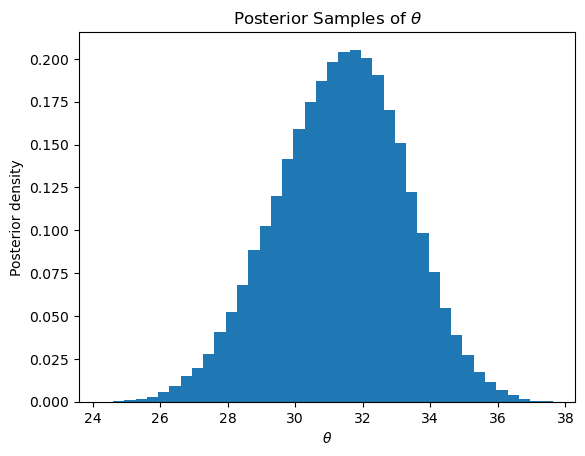

In [3]:
plt.hist(theta_samples, bins=40, density=True)
plt.xlabel(r"$\theta$")
plt.ylabel("Posterior density")
plt.title("Posterior Samples of $\\theta$")
plt.show()

This method is actually called the Bayesian bootstrap because it is very close to the bootstrap operationally, as demonstrated below. 

The usual bootstrap generates samples of the form: 
\begin{align*}
   \sum_{i=1}^n v_i \delta_{\{x_i\}} ~~ \text{ where } ~~ (v_1, \dots, v_n) \sim \frac{1}{n}\text{Multinomial}(n; 1/n, \dots, 1/n). 
\end{align*}
This leads to samples of $\theta$ (which is the mean of $P$) generated according to: 
\begin{align*}
   \sum_{i=1}^n v_i x_i ~~ \text{ where } ~~ (v_1, \dots, v_n) \sim \frac{1}{n}\text{Multinomial}(n; 1/n, \dots, 1/n). 
\end{align*}

In [4]:
#Bootstrap samples
V = np.random.multinomial(n=n, pvals=np.ones(n)/n, size=M)/n
theta_bootstrap = V @ x_obs

Below we plot the histograms of the bootstrap and Bayesian bootstrap samples. 

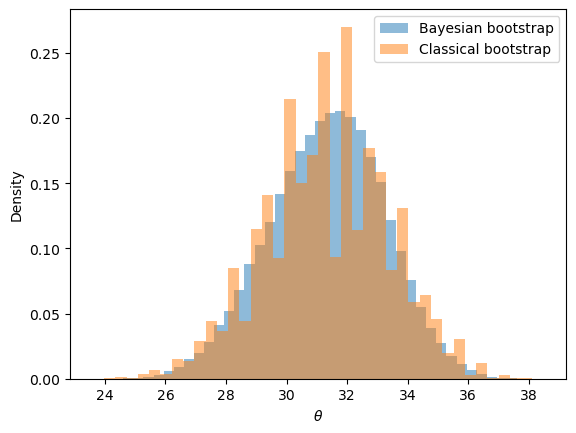

In [5]:
plt.hist(theta_samples, bins=40, density=True, alpha=0.5, label="Bayesian bootstrap")
plt.hist(theta_bootstrap, bins=40, density=True, alpha=0.5, label="Classical bootstrap")
plt.legend()
plt.xlabel(r"$\theta$")
plt.ylabel("Density")
plt.show()

The two histograms overlap considerably, but the classical bootstrap histogram is much rougher compared to the Bayesian bootstrap histogram. 

Below we compute the bootstrap mean and confidence intervals, and compare them to the Bayesian bootstrap mean and confidence intervals.

In [6]:
theta_mean_bootstrap = np.mean(theta_bootstrap)
theta_ci_bootstrap = np.quantile(theta_bootstrap, [0.025, 0.975])

print(f"Bootstrap mean of theta: {theta_mean_bootstrap:.2f}")
print(f"95% bootstrap confidence interval: [{theta_ci_bootstrap[0]:.2f}, {theta_ci_bootstrap[1]:.2f}]")

print(f"Posterior mean (Bayesian Bootstrap) of theta: {theta_mean:.2f}")
print(f"95% credible (Bayesian Bootstrap) interval: [{theta_ci[0]:.2f}, {theta_ci[1]:.2f}]")

Bootstrap mean of theta: 31.35
95% bootstrap confidence interval: [27.13, 35.15]
Posterior mean (Bayesian Bootstrap) of theta: 31.35
95% credible (Bayesian Bootstrap) interval: [27.53, 34.90]


Note that these intervals are very close to each other but the Bayesian bootstrap interval is slightly narrower. It can be checked that: 
\begin{align*}
   \mathbb{E} \left(\theta \mid \text{data} \right) = \mathbb{E} \left(\sum_{i=1}^n w_i x_i \mid \text{data} \right) = \bar{x} ~~ \text{ and } ~~ \text{var} \left(\theta \mid \text{data}  \right) = \text{var} \left(\sum_{i=1}^n w_i x_i \mid \text{data}  \right) = \frac{1}{n(n+1)} \sum_{i=1}^n (x_i - \bar{x})^2. 
\end{align*}
and
\begin{align*}
   \mathbb{E} \left(\sum_{i=1}^n v_i x_i \mid \text{data} \right) = \bar{x} ~~ \text{ and } ~~ \text{var} \left(\sum_{i=1}^n v_i x_i \mid \text{data} \right) = \frac{1}{n} \frac{1}{n} \sum_{i=1}^n (x_i - \bar{x})^2
\end{align*}
So the Bayesian bootstrap variance is very slightly (by a factor of $n/(n+1)$) smaller than the bootstrap variance. 


### Median Estimation

Instead of assuming that $\theta$ is the mean of $P$, we can assume that $\theta$ is the median of $P$. We would then be computing the medians of the generated samples (either the Bayesian bootstrap samples, or the usual bootstrap samples).

For an arbitrary probability measure $Q$, we define its median as: 
\begin{align*}
   \inf \left\{x: Q(-\infty, x] \geq 0.5 \right\} 
\end{align*}
This definition makes sense even when $Q$ is discrete. As an example, note that if $Q$ is the discrete distribution taking the two values 0 and 1 with equal probabilities, then the median of $Q$ according to the above definition is 0. 

Below we compute the medians corresponding to each Bayesian boostrap sample. 

In [7]:
order_obs = np.argsort(x_obs)
x_sorted = x_obs[order_obs]
W_sorted = W[:, order_obs]
cdf = np.cumsum(W_sorted, axis=1)
median_idx = np.argmax(cdf >= 0.5, axis=1)
theta_median_samples = x_sorted[median_idx]

In [8]:
theta_median_mean = np.mean(theta_median_samples)
theta_median_ci = np.quantile(theta_median_samples, [0.025, 0.975])

print(f"Posterior mean (Bayesian Bootstrap) of theta (median): {theta_median_mean:.2f}")
print(f"95% credible (Bayesian Bootstrap) interval for theta (median): [{theta_median_ci[0]:.2f}, {theta_median_ci[1]:.2f}]")

#Compare to mean: 
print(f"Posterior mean (Bayesian Bootstrap) of theta (mean): {theta_mean:.2f}")
print(f"95% credible (Bayesian Bootstrap) interval for theta (mean): [{theta_ci[0]:.2f}, {theta_ci[1]:.2f}]")

Posterior mean (Bayesian Bootstrap) of theta (median): 31.78
95% credible (Bayesian Bootstrap) interval for theta (median): [23.60, 38.50]
Posterior mean (Bayesian Bootstrap) of theta (mean): 31.35
95% credible (Bayesian Bootstrap) interval for theta (mean): [27.53, 34.90]


Next we do the same thing for the usual bootstrap. 

In [9]:
order_obs = np.argsort(x_obs)
x_sorted = x_obs[order_obs]
V_sorted = V[:, order_obs]
cdf = np.cumsum(V_sorted, axis=1)
median_idx = np.argmax(cdf >= 0.5, axis=1)
theta_median_bootstrap = x_sorted[median_idx]

In [10]:
theta_median_bootstrap_mean = np.mean(theta_median_bootstrap)
theta_median_bootstrap_ci = np.quantile(theta_median_bootstrap, [0.025, 0.975])

print(f"Posterior mean (Bootstrap) of theta (median): {theta_median_bootstrap_mean:.2f}")
print(f"95% credible (Bootstrap) interval for theta (median): [{theta_median_bootstrap_ci[0]:.2f}, {theta_median_bootstrap_ci[1]:.2f}]")

#Compare to mean: 
print(f"Posterior mean (Bootstrap) of theta (mean): {theta_mean_bootstrap:.2f}")
print(f"95% credible (Bootstrap) interval for theta (mean): [{theta_ci_bootstrap[0]:.2f}, {theta_ci_bootstrap[1]:.2f}]")

Posterior mean (Bootstrap) of theta (median): 30.51
95% credible (Bootstrap) interval for theta (median): [23.60, 34.40]
Posterior mean (Bootstrap) of theta (mean): 31.35
95% credible (Bootstrap) interval for theta (mean): [27.13, 35.15]


The histograms of the two median samples (Bootstrap and Bayesian Bootstrap) are plotted below. 

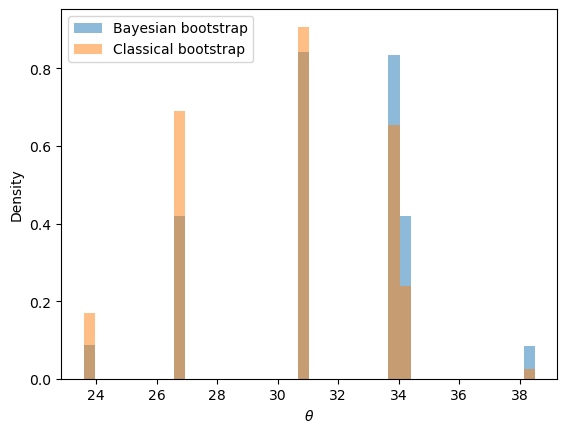

In [11]:
plt.hist(theta_median_samples, bins=40, density=True, alpha=0.5, label="Bayesian bootstrap")
plt.hist(theta_median_bootstrap, bins=40, density=True, alpha=0.5, label="Classical bootstrap")
plt.legend()
plt.xlabel(r"$\theta$")
plt.ylabel("Density")
plt.show()

For more on the Bayesian bootstrap and its connection to the classical bootstrap, I highly recommend the blog post https://www.sumsar.net/blog/2015/04/the-non-parametric-bootstrap-as-a-bayesian-model/ and the original paper on the Bayesian Bootstrap by Donald Rubin (1981). 